In [1]:
import numpy as np
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("D:\Projects\Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 91.3 KB


In [4]:
df.dtypes

Order_ID                    int64
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

In [5]:
df.isna().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [6]:
for i in df.columns:

    if pd.api.types.is_numeric_dtype(df[i]):
        df[i] = df[i].fillna(df[i].median())
    else:
        df[i] = df[i].fillna(df[i].mode()[0])

In [7]:
df.isna().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
X = df.drop(["Delivery_Time_min", "Order_ID"], axis=1)

y = df["Delivery_Time_min"]

In [10]:
X.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0
1,16.42,Clear,Medium,Evening,Bike,20,2.0
2,9.52,Foggy,Low,Night,Scooter,28,1.0
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0
4,19.03,Clear,Low,Morning,Bike,16,5.0


In [11]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

X.head()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,12,1.0,0,0,0,1,1,0,0,0,0,0,1
1,16.42,20,2.0,0,0,0,0,0,1,1,0,0,0,0
2,9.52,28,1.0,1,0,0,0,1,0,0,0,1,0,1
3,7.44,5,1.0,0,1,0,0,0,1,0,0,0,0,1
4,19.03,16,5.0,0,0,0,0,1,0,0,1,0,0,0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

# Train using training data
model.fit(X_train, y_train)

# Predict on unseen test data
prediction = model.predict(X_test)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

X_train shape: (800, 14)
X_test shape: (200, 14)


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, prediction)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.899168698353487
MSE: 77.90657530660577
RMSE: 8.826470149873378
R2 Score: 0.8261894538886113


In [15]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Ridge
ridge_scaled = Ridge(alpha=1.0)
ridge_scaled.fit(X_train_scaled, y_train)

ridge_pred_scaled = ridge_scaled.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, ridge_pred_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred_scaled)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred_scaled)

# Lasso
lasso_scaled = Lasso(alpha=0.1)
lasso_scaled.fit(X_train_scaled, y_train)

lasso_pred_scaled = lasso_scaled.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, lasso_pred_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred_scaled)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred_scaled)

print("Ridge (Scaled)")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

print("\nLasso (Scaled)")
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)
print("R2 Score:", lasso_r2)

Ridge (Scaled)
MAE: 5.904006580554253
MSE: 77.94519218810771
RMSE: 8.828657439730444
R2 Score: 0.8261032991418964

Lasso (Scaled)
MAE: 5.978322459621746
MSE: 79.1911536567845
RMSE: 8.898941153687021
R2 Score: 0.8233235434864569


In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

cv_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation R2 scores:", cv_scores)
print("Mean R2:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation R2 scores: [0.70307888 0.80689978 0.78757919 0.75516701 0.78994626]
Mean R2: 0.7685342237868473
Standard Deviation: 0.03675918033980176


In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    print(name)
    print("Scores:", scores)
    print("Mean R2:", scores.mean())
    print("Std:", scores.std())
    print("-" * 40)

Linear Regression
Scores: [0.70307888 0.80689978 0.78757919 0.75516701 0.78994626]
Mean R2: 0.7685342237868473
Std: 0.03675918033980176
----------------------------------------
Ridge
Scores: [0.70265355 0.80698089 0.78789588 0.75544922 0.79021145]
Mean R2: 0.7686381987015414
Std: 0.0369712031427343
----------------------------------------
Lasso
Scores: [0.69661343 0.80811664 0.78986623 0.75630468 0.79227816]
Mean R2: 0.7686358279359955
Std: 0.039768599862716726
----------------------------------------


In [18]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

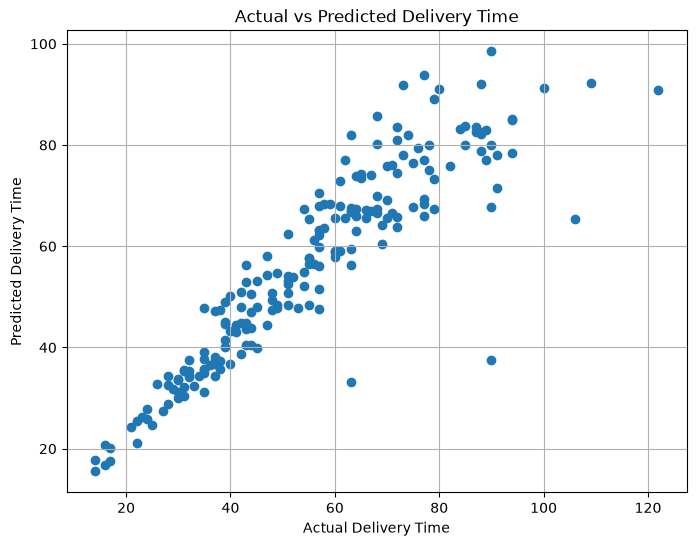

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, lr_prediction)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.grid()
plt.show()

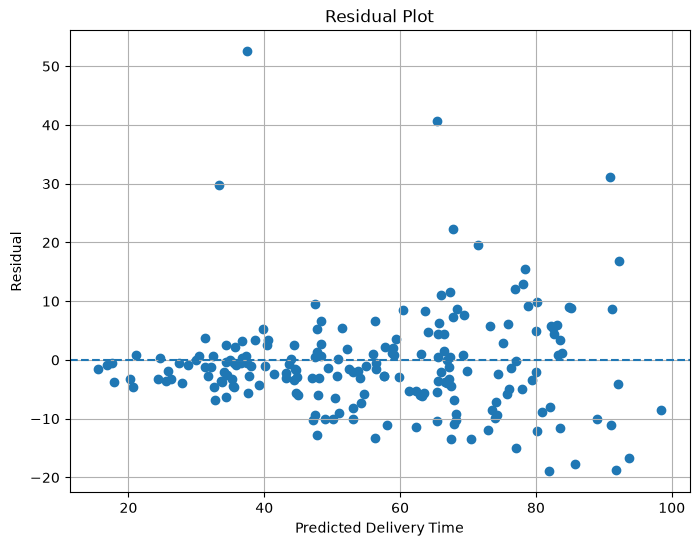

In [20]:
residuals = y_test - lr_prediction

plt.figure(figsize=(8, 6))

plt.scatter(lr_prediction, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.grid()
plt.show()

In [21]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    )
    
    results.append((alpha, scores.mean()))

for alpha, score in results:
    print("Alpha:", alpha, "Mean R2:", score)

Alpha: 0.001 Mean R2: 0.7525331119400348
Alpha: 0.01 Mean R2: 0.7525333434944764
Alpha: 0.1 Mean R2: 0.7525356370185032
Alpha: 1 Mean R2: 0.752556379985671
Alpha: 10 Mean R2: 0.7525539388497836
Alpha: 100 Mean R2: 0.7381330705953937
Alpha: 1000 Mean R2: 0.46373067922909783


In [22]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_ridge = Ridge(alpha=1)

best_ridge.fit(X_train_scaled, y_train)

ridge_final_prediction = best_ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, ridge_final_prediction)
mse = mean_squared_error(y_test, ridge_final_prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, ridge_final_prediction)

print("Best Ridge Model")
print("Alpha:", best_ridge.alpha)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Best Ridge Model
Alpha: 1
MAE: 5.904006580554253
MSE: 77.94519218810771
RMSE: 8.828657439730444
R2 Score: 0.8261032991418964


In [23]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

results = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    )

    results.append((alpha, scores.mean()))

for alpha, score in results:
    print("Alpha:", alpha, "Mean R2:", score)

Alpha: 0.0001 Mean R2: 0.7525336011900297
Alpha: 0.001 Mean R2: 0.752538204100969
Alpha: 0.01 Mean R2: 0.7525800338691738
Alpha: 0.1 Mean R2: 0.7525190474895779
Alpha: 1 Mean R2: 0.7283985755779046
Alpha: 10 Mean R2: 0.39289029463976577


In [24]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_lasso = Lasso(alpha=0.01, max_iter=10000)

best_lasso.fit(X_train_scaled, y_train)

lasso_final_prediction = best_lasso.predict(X_test_scaled)

mae = mean_absolute_error(y_test, lasso_final_prediction)
mse = mean_squared_error(y_test, lasso_final_prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lasso_final_prediction)

print("Best Lasso Model")
print("Alpha:", best_lasso.alpha)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Best Lasso Model
Alpha: 0.01
MAE: 5.906253039265119
MSE: 78.01898119634485
RMSE: 8.832835399595355
R2 Score: 0.8259386749395329


In [25]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()

final_model.fit(X, y)

print("Final model trained successfully!")

Final model trained successfully!


In [26]:
import joblib

joblib.dump(final_model, "linear_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [27]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [30]:
import pandas as pd
import joblib

model = joblib.load("linear_regression_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

def predict_delivery_time(
    distance,
    weather,
    traffic_level,
    time_of_day,
    vehicle_type,
    preparation_time,
    courier_experience
):
    
    input_data = pd.DataFrame({
        "Distance_km": [distance],
        "Weather": [weather],
        "Traffic_Level": [traffic_level],
        "Time_of_Day": [time_of_day],
        "Vehicle_Type": [vehicle_type],
        "Preparation_Time_min": [preparation_time],
        "Courier_Experience_yrs": [courier_experience]
    })

    input_data = pd.get_dummies(
        input_data,
        drop_first=True,
        dtype=int
    )

    input_data = input_data.reindex(
        columns=feature_columns,
        fill_value=0
    )

    prediction = model.predict(input_data)

    return prediction[0]

In [31]:
result = predict_delivery_time(
    distance=8,
    weather="Clear",
    traffic_level="Medium",
    time_of_day="Evening",
    vehicle_type="Bike",
    preparation_time=20,
    courier_experience=2
)

print("Predicted Delivery Time:", round(result, 2), "minutes")

Predicted Delivery Time: 59.57 minutes


In [32]:
import pandas as pd

# Get feature coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Add absolute coefficient
coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

# Sort by importance
coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
7,Traffic_Level_Low,-11.932655,11.932655
5,Weather_Snowy,9.304308,9.304308
3,Weather_Foggy,7.352224,7.352224
8,Traffic_Level_Medium,-6.188154,6.188154
4,Weather_Rainy,4.843582,4.843582
0,Distance_km,2.991081,2.991081
6,Weather_Windy,1.940991,1.940991
1,Preparation_Time_min,0.966878,0.966878
13,Vehicle_Type_Scooter,-0.867977,0.867977
9,Time_of_Day_Evening,0.856347,0.856347


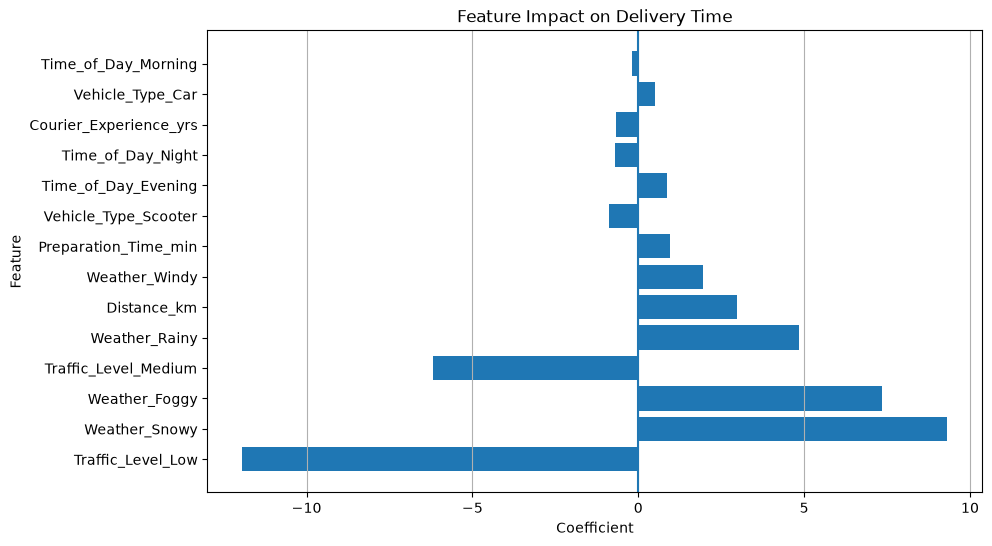

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Impact on Delivery Time")
plt.axvline(0)
plt.grid(axis="x")

plt.show()